# Setup

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob

import librosa 
import librosa.display
import IPython.display as ipd 

# Reading Audio files

In [2]:
glob("/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/*.wav")

['/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/1-104089-A-22.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/3-246513-B-16.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/1-96950-B-9.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/2-105270-A-47.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/4-90014-B-42.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/1-47273-A-21.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/1-39901-A-11.wav',
 '/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/1-19840-A-36.wav',
 '/Users/filipapopova/source/repos/Amb

In [3]:
# Load ESC-50 metadata
esc50_csv_path = '../data/raw/ESC-50-master/meta/esc50.csv'
df_esc50 = pd.read_csv(esc50_csv_path)

print("ESC-50 Head:")
display(df_esc50.head())

ESC-50 Head:


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [4]:
audio_files = glob("/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/data/raw/ESC-50-master/audio/*.wav")

#Play Audio file
ipd.Audio(audio_files[0])

### Класове в ESC 50


In [5]:
categories = df_esc50['category'].unique()
n_categories = len(categories)

print(f"Number of unique categories: {n_categories}")
print("Categories:")
print(categories)

Number of unique categories: 50
Categories:
<StringArray>
[             'dog',   'chirping_birds',   'vacuum_cleaner',
     'thunderstorm',  'door_wood_knock',      'can_opening',
             'crow',         'clapping',        'fireworks',
         'chainsaw',         'airplane',      'mouse_click',
    'pouring_water',            'train',            'sheep',
      'water_drops',     'church_bells',      'clock_alarm',
  'keyboard_typing',             'wind',        'footsteps',
             'frog',              'cow',   'brushing_teeth',
         'car_horn',   'crackling_fire',       'helicopter',
 'drinking_sipping',             'rain',          'insects',
         'laughing',              'hen',           'engine',
        'breathing',      'crying_baby',         'hand_saw',
         'coughing',   'glass_breaking',          'snoring',
     'toilet_flush',              'pig',  'washing_machine',
       'clock_tick',         'sneezing',          'rooster',
        'sea_waves',       

In [6]:
y, sr = librosa.load(audio_files[0])

print(f"y: {y[50:60]}")
print(f"y shape {y.shape}")
print(f"sample rate: {sr}")

/Users/filipapopova/source/repos/Ambient-Sound-Awareness-System-ASAS-/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


y: [-0.00063211  0.00010419 -0.00097025  0.0003908   0.00070818 -0.0003564
  0.00159619 -0.00023748  0.00087969 -0.00017178]
y shape (110250,)
sample rate: 22050


<Axes: title={'center': 'Raw Audio Example'}>

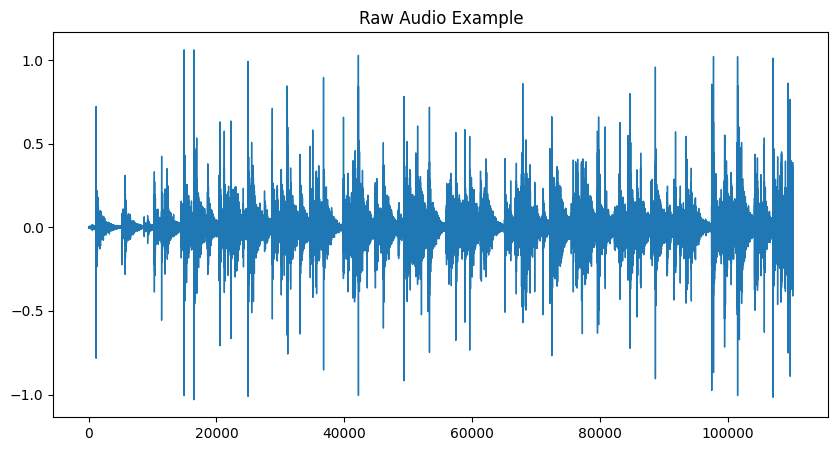

In [7]:
pd.Series(y).plot(figsize=[10, 5], lw = 1, title = "Raw Audio Example")

<Axes: title={'center': 'Raw Audio Trimmed Example'}>

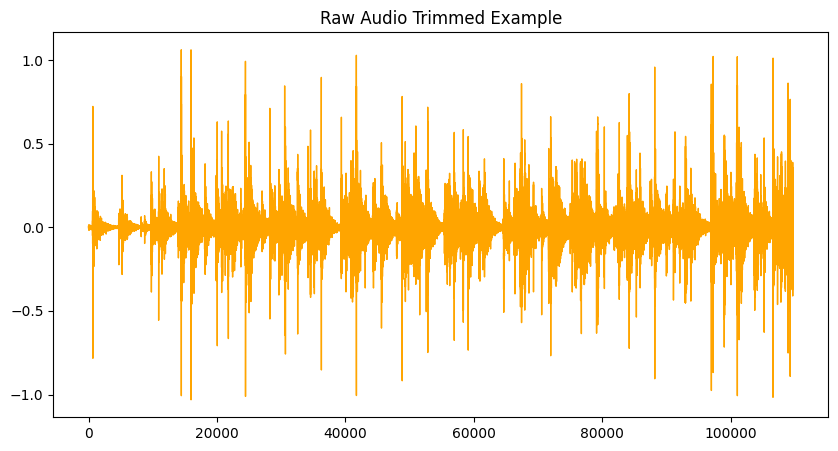

In [8]:
y_trimmed, _ = librosa.effects.trim(y, top_db=20)

pd.Series(y_trimmed).plot(
    figsize = (10, 5),
    lw = 1,
    title = "Raw Audio Trimmed Example",
    color = "orange"
)


<Axes: title={'center': 'Raw Audio Zoomed Example'}>

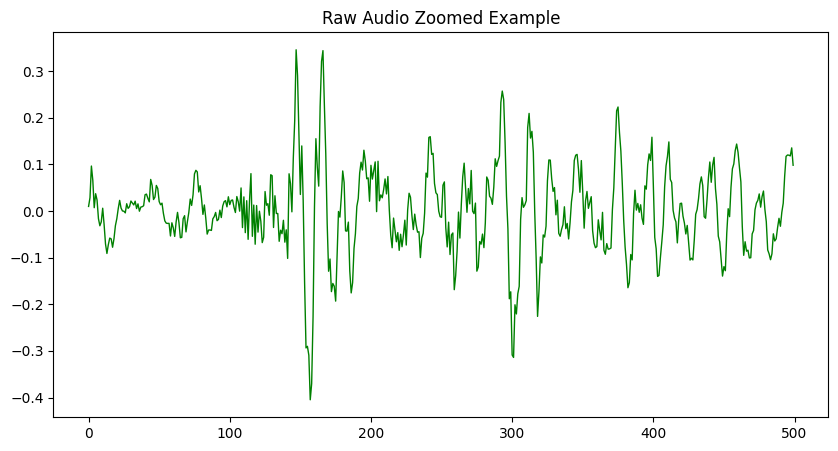

In [9]:
pd.Series(y[30000:30500]).plot(
    figsize = (10, 5),
    lw = 1,
    title = "Raw Audio Zoomed Example",
    color = "green"
)

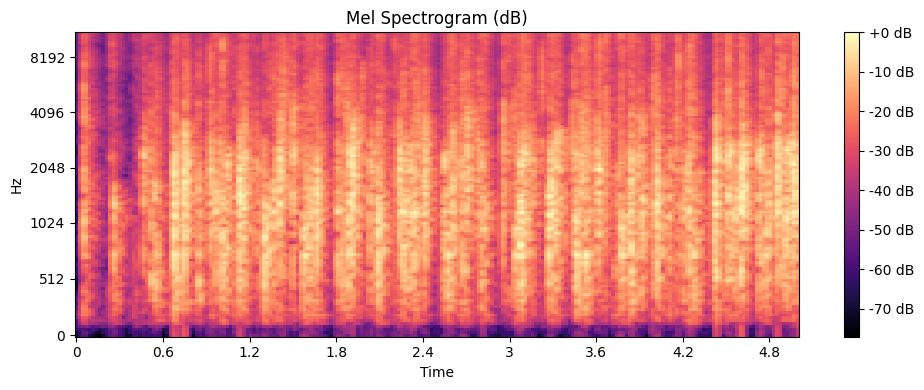

In [10]:
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128,
    fmax=8000
)

mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

plt.figure(figsize=(10, 4), )
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram (dB)")
plt.tight_layout()
plt.show()